# Synthetic datasets evaluation on Adult dataset.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

# stdlib
import os
import sys
from pathlib import Path
import random

sys.path.append('..')
sys.path.append('../libs/MIA-synthetic-main')
os.environ['OMP_PATH'] = '/opt/homebrew/Cellar/libomp/19.1.3/include'

# third-party
import pandas as pd
import numpy as np

from tapas.datasets import TabularDataset
from tapas.generators.generator import ReprosynGenerator

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from synthcity.plugins.core.dataloader import GenericDataLoader
from synthcity.metrics.eval_statistical import AlphaPrecision

from reprosyn.methods import DS_PRIVBAYES
from sdmetrics.reports.single_table import QualityReport
from hydra import initialize, compose

# custom
from tools.synthetic_evaluation.quality_evaluation import convert_metadata_to_sdm_format
from tools.synthetic_evaluation.classification_optimizer import ClassificationOptimizer
from tools.tapas.utils import get_categorical_and_numerical_features
from tools.tapas.tapas_data_processors import AdultDataProcessor

[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode


In [2]:
os.getcwd()

'/Users/taapeco3/Documents/master_thesis/dev/colin-pelletier/privacy/notebooks'

In [3]:
os.chdir('../')

In [ ]:
DATASET_NAME = 'adult'
RANDOM_STATE=42
gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", seed=RANDOM_STATE,
                        histogram_bins=18, degree=3, epsilon=1.0)
CLF_CONFIG = f'{DATASET_NAME}_best'
GENERATOR_ID = "PrivBayes" # to export model comparison results

# reproducibility
np.random.seed(RANDOM_STATE)
pd.np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# for final dataset display
results = []

# IO
DATA_FOLDER = Path('./data')
OUTPUT_FOLDER = Path('./generated/generators_comparison')
OUTPUT_FOLDER_EDA = OUTPUT_FOLDER/'eda'
# from ./privacy
PRIVACY_EXPERIMENT_DIR = "./experiments/privacy"

# 1k experiment

## Load data

In [9]:
N_SYNTH_SAMPLES = 1000
N_TEST_SAMPLES = 200

DATA_PATH = Path(f'./data/{DATASET_NAME}')
full_ds = TabularDataset.read(DATA_PATH, label=DATASET_NAME)
full_ds = AdultDataProcessor.process_tapas_tabulardataset(full_ds)
categorical_features = full_ds.description.one_hot_cols
numerical_features = [col for col in full_ds.description.columns if col not in categorical_features]

# pre-define test samples for ML utility
np_rng = np.random.default_rng(RANDOM_STATE)
record_ids = np_rng.integers(0, len(full_ds.data), N_SYNTH_SAMPLES+N_TEST_SAMPLES)
train_records_ids = record_ids[:N_SYNTH_SAMPLES]
test_records_ids = record_ids[N_SYNTH_SAMPLES:]
test_ds = full_ds.get_records(test_records_ids)
train_ds = full_ds.get_records(train_records_ids)

results_exp = {
    'N_SYNTH_SAMPLES': N_SYNTH_SAMPLES,
    'N_TEST_SAMPLES': N_TEST_SAMPLES,
    'DATASET_NAME': DATASET_NAME
    }

## Generate synthetic datasets

In [10]:
gen.fit(train_ds)
synth_data = gen.generate(N_SYNTH_SAMPLES)

## Statistical similarity evaluation

In [11]:
metadata = convert_metadata_to_sdm_format(full_ds.description.schema)
quality_report = QualityReport()
quality_report.generate(train_ds.data, synth_data.data, metadata)
fig = quality_report.get_visualization(property_name='Column Shapes')
fig.show()

results_exp['Column Pair Trends'] = quality_report.get_details('Column Pair Trends').mean()['Score']
results_exp['Column Shapes'] = quality_report.get_details('Column Shapes').mean()['Score']

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 1527.35it/s]|
Column Shapes Score: 47.9%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 362.75it/s]|
Column Pair Trends Score: 38.85%

Overall Score (Average): 43.38%



## ML Utility

In [ ]:
# Use hydra configuration file with the optimal hyperparameters
with initialize(config_path="../configs/classifier_hpo", version_base=None):
    cfg = compose(config_name=CLF_CONFIG)

clf_opt = ClassificationOptimizer(cfg, synth_data, test_ds)
clf_opt.fit()

cv_scores_mean, cv_scores_std = clf_opt.evaluate_classifier()
test_scores_mean, test_scores_low_ci, test_scores_high_ci = clf_opt.test_classifier(n_repetitions=100)
results_exp['CV Mean'] = cv_scores_mean
results_exp['CV Std'] = cv_scores_std
results_exp['Test Mean'] = test_scores_mean
results_exp['Test Low CI'] = test_scores_low_ci
results_exp['Test High CI'] = test_scores_high_ci

print(f"CV scores mean: {cv_scores_mean:.3f} (+/- {cv_scores_std:.3f})")
print(f"Test scores mean: {test_scores_mean:.3f} ({test_scores_low_ci:.3f}-{test_scores_high_ci:.3f})")

CV scores mean: 0.532 (+/- 0.015)
Test scores mean: 0.226 (0.172-0.279)


## Authenticity

In [13]:
def encode_features(dataset):
    data_description = dataset.description
    df = dataset.data.copy()
    categorical_features, numerical_features = get_categorical_and_numerical_features(data_description)
    categories = {col["name"]: col["representation"] for col in data_description if col['name'] in categorical_features}
    categories = [categories[col] for col in dataset.data.columns if col in categorical_features]
    ohe = OneHotEncoder(sparse_output=False, categories=categories, handle_unknown='ignore')

    preprocessor = ColumnTransformer([
        ('numerical', StandardScaler(), numerical_features),
        ('categorical', ohe, categorical_features)
    ])

    return preprocessor.fit_transform(df)

train_loader = GenericDataLoader(encode_features(train_ds), random_state=RANDOM_STATE)
synth_loader = GenericDataLoader(encode_features(synth_data), random_state=RANDOM_STATE)

alpha_precision = AlphaPrecision()
alpha_precision = alpha_precision.evaluate(train_loader, synth_loader)

results_exp['Authenticity'] = alpha_precision['authenticity_OC']
print("Authenticity:", alpha_precision['authenticity_OC'])

results.append(results_exp)

Authenticity: 0.814


In [14]:
pd.DataFrame(results_exp, index=[DATASET_NAME]).round(3)

,N_SYNTH_SAMPLES,N_TEST_SAMPLES,DATASET_NAME,Column Pair Trends,Column Shapes,CV Mean,CV Std,Test Mean,Test Low CI,Test High CI,Authenticity
adult,1000,200,adult,0.389,0.479,0.532,0.015,0.226,0.172,0.279,0.814


# 10k experiment

## Load data

In [15]:
N_SYNTH_SAMPLES = 10000
N_TEST_SAMPLES = 2000

DATA_PATH = Path(f'./data/{DATASET_NAME}')
full_ds = TabularDataset.read(DATA_PATH, label=DATASET_NAME)
full_ds = AdultDataProcessor.process_tapas_tabulardataset(full_ds)
categorical_features = full_ds.description.one_hot_cols
numerical_features = [col for col in full_ds.description.columns if col not in categorical_features]

# pre-define test samples for ML utility
np_rng = np.random.default_rng(RANDOM_STATE)
record_ids = np_rng.integers(0, len(full_ds.data), N_SYNTH_SAMPLES+N_TEST_SAMPLES)
train_records_ids = record_ids[:N_SYNTH_SAMPLES]
test_records_ids = record_ids[N_SYNTH_SAMPLES:]
test_ds = full_ds.get_records(test_records_ids)
train_ds = full_ds.get_records(train_records_ids)

results_exp = {
    'N_SYNTH_SAMPLES': N_SYNTH_SAMPLES,
    'N_TEST_SAMPLES': N_TEST_SAMPLES,
    'DATASET_NAME': DATASET_NAME
    }

## Generate synthetic datasets

In [16]:
gen.fit(train_ds)
synth_data = gen.generate(N_SYNTH_SAMPLES)

## Statistical similarity evaluation

In [17]:
metadata = convert_metadata_to_sdm_format(full_ds.description.schema)
quality_report = QualityReport()
quality_report.generate(train_ds.data, synth_data.data, metadata)
fig = quality_report.get_visualization(property_name='Column Shapes')
fig.show()

results_exp['Column Pair Trends'] = quality_report.get_details('Column Pair Trends').mean()['Score']
results_exp['Column Shapes'] = quality_report.get_details('Column Shapes').mean()['Score']

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 264.21it/s]|
Column Shapes Score: 48.52%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 253.62it/s]|
Column Pair Trends Score: 39.74%

Overall Score (Average): 44.13%



## ML Utility

In [ ]:
# Use hydra configuration file with the optimal hyperparameters
with initialize(config_path="../configs/classifier_hpo", version_base=None):
    cfg = compose(config_name=CLF_CONFIG)

clf_opt = ClassificationOptimizer(cfg, synth_data, test_ds)
clf_opt.fit()

cv_scores_mean, cv_scores_std = clf_opt.evaluate_classifier()
test_scores_mean, test_scores_low_ci, test_scores_high_ci = clf_opt.test_classifier(n_repetitions=100)
results_exp['CV Mean'] = cv_scores_mean
results_exp['CV Std'] = cv_scores_std
results_exp['Test Mean'] = test_scores_mean
results_exp['Test Low CI'] = test_scores_low_ci
results_exp['Test High CI'] = test_scores_high_ci

print(f"CV scores mean: {cv_scores_mean:.3f} (+/- {cv_scores_std:.3f})")
print(f"Test scores mean: {test_scores_mean:.3f} ({test_scores_low_ci:.3f}-{test_scores_high_ci:.3f})")

CV scores mean: 0.633 (+/- 0.006)
Test scores mean: 0.594 (0.574-0.618)


## Authenticity

In [19]:
def encode_features(dataset):
    data_description = dataset.description
    df = dataset.data.copy()
    categorical_features, numerical_features = get_categorical_and_numerical_features(data_description)
    categories = {col["name"]: col["representation"] for col in data_description if col['name'] in categorical_features}
    categories = [categories[col] for col in dataset.data.columns if col in categorical_features]
    ohe = OneHotEncoder(sparse_output=False, categories=categories, handle_unknown='ignore')

    preprocessor = ColumnTransformer([
        ('numerical', StandardScaler(), numerical_features),
        ('categorical', ohe, categorical_features)
    ])

    return preprocessor.fit_transform(df)

train_loader = GenericDataLoader(encode_features(train_ds), random_state=RANDOM_STATE)
synth_loader = GenericDataLoader(encode_features(synth_data), random_state=RANDOM_STATE)

alpha_precision = AlphaPrecision()
alpha_precision = alpha_precision.evaluate(train_loader, synth_loader)

results_exp['Authenticity'] = alpha_precision['authenticity_OC']
print("Authenticity:", alpha_precision['authenticity_OC'])

results.append(results_exp)

Authenticity: 0.9037


In [20]:
pd.DataFrame(results_exp, index=[DATASET_NAME]).round(3)

,N_SYNTH_SAMPLES,N_TEST_SAMPLES,DATASET_NAME,Column Pair Trends,Column Shapes,CV Mean,CV Std,Test Mean,Test Low CI,Test High CI,Authenticity
adult,10000,2000,adult,0.397,0.485,0.633,0.006,0.594,0.574,0.618,0.904


# 30k experiment

## Load data

In [21]:
N_SYNTH_SAMPLES = 30000
N_TEST_SAMPLES = 5000

DATA_PATH = Path(f'./data/{DATASET_NAME}')
full_ds = TabularDataset.read(DATA_PATH, label=DATASET_NAME)
full_ds = AdultDataProcessor.process_tapas_tabulardataset(full_ds)
categorical_features = full_ds.description.one_hot_cols
numerical_features = [col for col in full_ds.description.columns if col not in categorical_features]

# pre-define test samples for ML utility
np_rng = np.random.default_rng(RANDOM_STATE)
record_ids = np_rng.integers(0, len(full_ds.data), N_SYNTH_SAMPLES+N_TEST_SAMPLES)
train_records_ids = record_ids[:N_SYNTH_SAMPLES]
test_records_ids = record_ids[N_SYNTH_SAMPLES:]
test_ds = full_ds.get_records(test_records_ids)
train_ds = full_ds.get_records(train_records_ids)

results_exp = {
    'N_SYNTH_SAMPLES': N_SYNTH_SAMPLES,
    'N_TEST_SAMPLES': N_TEST_SAMPLES,
    'DATASET_NAME': DATASET_NAME
    }

## Generate synthetic datasets

In [22]:
gen.fit(train_ds)
synth_data = gen.generate(N_SYNTH_SAMPLES)

## Statistical similarity evaluation

In [23]:
metadata = convert_metadata_to_sdm_format(full_ds.description.schema)
quality_report = QualityReport()
quality_report.generate(train_ds.data, synth_data.data, metadata)
fig = quality_report.get_visualization(property_name='Column Shapes')
fig.show()

results_exp['Column Pair Trends'] = quality_report.get_details('Column Pair Trends').mean()['Score']
results_exp['Column Shapes'] = quality_report.get_details('Column Shapes').mean()['Score']

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 115.54it/s]|
Column Shapes Score: 51.43%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 156.03it/s]|
Column Pair Trends Score: 43.04%

Overall Score (Average): 47.24%



## ML Utility

In [ ]:
# Use hydra configuration file with the optimal hyperparameters
with initialize(config_path="../configs/classifier_hpo", version_base=None):
    cfg = compose(config_name=CLF_CONFIG)

clf_opt = ClassificationOptimizer(cfg, synth_data, test_ds)
clf_opt.fit()

cv_scores_mean, cv_scores_std = clf_opt.evaluate_classifier()
test_scores_mean, test_scores_low_ci, test_scores_high_ci = clf_opt.test_classifier(n_repetitions=100)
results_exp['CV Mean'] = cv_scores_mean
results_exp['CV Std'] = cv_scores_std
results_exp['Test Mean'] = test_scores_mean
results_exp['Test Low CI'] = test_scores_low_ci
results_exp['Test High CI'] = test_scores_high_ci

print(f"CV scores mean: {cv_scores_mean:.3f} (+/- {cv_scores_std:.3f})")
print(f"Test scores mean: {test_scores_mean:.3f} ({test_scores_low_ci:.3f}-{test_scores_high_ci:.3f})")

CV scores mean: 0.712 (+/- 0.006)
Test scores mean: 0.613 (0.600-0.627)


## Authenticity

In [25]:
def encode_features(dataset):
    data_description = dataset.description
    df = dataset.data.copy()
    categorical_features, numerical_features = get_categorical_and_numerical_features(data_description)
    categories = {col["name"]: col["representation"] for col in data_description if col['name'] in categorical_features}
    categories = [categories[col] for col in dataset.data.columns if col in categorical_features]
    ohe = OneHotEncoder(sparse_output=False, categories=categories, handle_unknown='ignore')

    preprocessor = ColumnTransformer([
        ('numerical', StandardScaler(), numerical_features),
        ('categorical', ohe, categorical_features)
    ])

    return preprocessor.fit_transform(df)

train_loader = GenericDataLoader(encode_features(train_ds), random_state=RANDOM_STATE)
synth_loader = GenericDataLoader(encode_features(synth_data), random_state=RANDOM_STATE)

alpha_precision = AlphaPrecision()
alpha_precision = alpha_precision.evaluate(train_loader, synth_loader)

results_exp['Authenticity'] = alpha_precision['authenticity_OC']
print("Authenticity:", alpha_precision['authenticity_OC'])

results.append(results_exp)

Authenticity: 0.9381


In [26]:
pd.DataFrame(results_exp, index=[DATASET_NAME]).round(3)

,N_SYNTH_SAMPLES,N_TEST_SAMPLES,DATASET_NAME,Column Pair Trends,Column Shapes,CV Mean,CV Std,Test Mean,Test Low CI,Test High CI,Authenticity
adult,30000,5000,adult,0.43,0.514,0.712,0.006,0.613,0.6,0.627,0.938


# Experiment summary

In [27]:
results_df = pd.DataFrame(results).set_index('N_SYNTH_SAMPLES')
results_df.to_csv(OUTPUT_FOLDER/f"{DATASET_NAME}_{GENERATOR_ID}_evaluation_results.csv")

results_df

,N_TEST_SAMPLES,DATASET_NAME,Column Pair Trends,Column Shapes,CV Mean,CV Std,Test Mean,Test Low CI,Test High CI,Authenticity
N_SYNTH_SAMPLES,,,,,,,,,,
1000,200,adult,0.388542,0.479000,0.532196,0.014915,0.226177,0.172365,0.278568,0.8140
10000,2000,adult,0.397429,0.485187,0.632936,0.006001,0.594177,0.574447,0.618382,0.9037
30000,5000,adult,0.430397,0.514327,0.712007,0.005873,0.613115,0.599797,0.627478,0.9381


## Privacy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


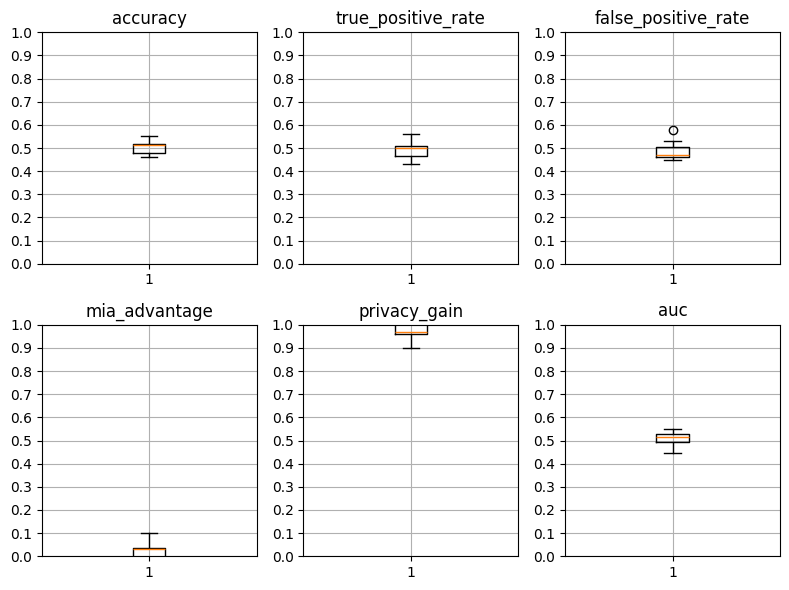

In [5]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')
from tools.utils import get_privacy_summaries, plot_privacy_metrics

GENERATOR_ID = "PrivBayes"
DATASET_NAME = "adult"
PRIVACY_EXPERIMENT_DIR = "./experiments/privacy"
OUTPUT_FOLDER = Path('./generated/generators_comparison')
SELECTED_GENERATORS = [GENERATOR_ID]
SELECTED_DATASETS = [DATASET_NAME]

# Display the combined DataFrame
privacy_summaries = get_privacy_summaries(PRIVACY_EXPERIMENT_DIR, SELECTED_DATASETS, SELECTED_GENERATORS)

# export to csv
privacy_summaries.to_csv(OUTPUT_FOLDER/f"{DATASET_NAME}_{GENERATOR_ID}_privacy_results.csv")
plot_privacy_metrics(privacy_summaries)